# 01 — Data Cleaning
## Superstore Sales Dashboard · Proyecto 3

**Objetivo:** Cargar el dataset raw, inspeccionar su calidad, limpiar los datos y aplicar feature engineering para dejar el dataset listo para el análisis exploratorio.

**Outputs:**
- `../data/superstore_clean.csv` → dataset limpio y enriquecido

---
**Stack:** Python · pandas · numpy

## 1. Imports y configuración

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)

print("Librerías cargadas correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")

Librerías cargadas correctamente
   pandas  2.3.3
   numpy   2.2.6


## 2. Carga del dataset

Cargamos el CSV raw con encoding `latin-1` (necesario para caracteres especiales del dataset original de Superstore).

In [5]:
df = pd.read_csv("../data/superstore_raw.csv", encoding="latin-1")

print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head()

Dataset cargado: 9,994 filas x 21 columnas


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


## 3. Inspección inicial

Revisamos tipos de datos, valores nulos y estadísticas básicas antes de tomar decisiones de limpieza.

In [6]:
# Tipos de datos y valores no nulos
print("=" * 55)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 55)
df.info()

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 

In [7]:
# Vista de columnas con su tipo de dato
print("\n Columnas y tipos de dato:")
print("-" * 40)
for col in df.columns:
    print(f"  {col:<30} {str(df[col].dtype):<12}")


 Columnas y tipos de dato:
----------------------------------------
  Row ID                         int64       
  Order ID                       object      
  Order Date                     object      
  Ship Date                      object      
  Ship Mode                      object      
  Customer ID                    object      
  Customer Name                  object      
  Segment                        object      
  Country                        object      
  City                           object      
  State                          object      
  Postal Code                    int64       
  Region                         object      
  Product ID                     object      
  Category                       object      
  Sub-Category                   object      
  Product Name                   object      
  Sales                          float64     
  Quantity                       int64       
  Discount                       float64     
  Profit   

In [11]:
# Estadísticas descriptivas — columnas numéricas
print("\n Estadísticas descriptivas (numéricas):")
df.describe().T.style.background_gradient(cmap="Blues", subset=["mean", "std"])


 Estadísticas descriptivas (numéricas):


,count,mean,std,min,25%,50%,75%,max
Row ID,9994.000000,4997.500000,2885.163629,1.000000,2499.250000,4997.500000,7495.750000,9994.000000
Postal Code,9994.000000,55190.379428,32063.693350,1040.000000,23223.000000,56430.500000,90008.000000,99301.000000
Sales,9994.000000,229.858001,623.245101,0.444000,17.280000,54.490000,209.940000,22638.480000
Quantity,9994.000000,3.789574,2.225110,1.000000,2.000000,3.000000,5.000000,14.000000
Discount,9994.000000,0.156203,0.206452,0.000000,0.000000,0.200000,0.200000,0.800000
Profit,9994.000000,28.656896,234.260108,-6599.978000,1.728750,8.666500,29.364000,8399.976000


## 4. Análisis de valores nulos

In [14]:
# Conteo y porcentaje de nulos por columna
nulls = pd.DataFrame({
    "Nulos":      df.isnull().sum(),
    "% del total": (df.isnull().sum() / len(df) * 100).round(2)
})
nulls = nulls[nulls["Nulos"] > 0]

if nulls.empty:
    print(" No hay valores nulos en el dataset.")
else:
    print(f" Columnas con valores nulos ({len(nulls)}):")
    display(nulls.style.background_gradient(cmap="Reds"))

df.isnull().sum()

 No hay valores nulos en el dataset.


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## 5. Detección y eliminación de duplicados

In [15]:
n_dup = df.duplicated().sum()
print(f" Filas duplicadas detectadas: {n_dup}")

if n_dup > 0:
    df = df.drop_duplicates()
    print(f"   → Eliminadas. Filas restantes: {len(df):,}")
else:
    print(" No hay filas duplicadas.")

 Filas duplicadas detectadas: 0
 No hay filas duplicadas.


## 6. Limpieza de columnas

Normalizamos nombres de columnas, eliminamos espacios y verificamos que no haya columnas completamente vacías.

In [16]:
# Limpiar nombres de columnas (strip de espacios)
df.columns = df.columns.str.strip()
print(" Nombres de columnas normalizados")
print("\nColumnas finales:")
print(list(df.columns))

 Nombres de columnas normalizados

Columnas finales:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [18]:
# Limpiar espacios en columnas de texto
str_cols = df.select_dtypes(include="object").columns
for col in str_cols:
    df[col] = df[col].str.strip()

print(f" Espacios eliminados en {len(str_cols)} columnas de texto")

 Espacios eliminados en 15 columnas de texto


## 7. Parsing de fechas

Convertimos `Order Date` y `Ship Date` a tipo `datetime` y calculamos el **Ship Lag** (días entre pedido y envío).

In [19]:
# Antes de convertir
print("Tipos ANTES del parsing:")
print(f"  Order Date: {df['Order Date'].dtype}")
print(f"  Ship Date:  {df['Ship Date'].dtype}")
print(f"\nEjemplo de valores:")
print(df[['Order Date', 'Ship Date']].head(3).to_string(index=False))

Tipos ANTES del parsing:
  Order Date: object
  Ship Date:  object

Ejemplo de valores:
Order Date  Ship Date
 11/8/2016 11/11/2016
 11/8/2016 11/11/2016
 6/12/2016  6/16/2016


In [21]:
# Conversión a datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"]  = pd.to_datetime(df["Ship Date"])

print("Tipos DESPUÉS del parsing:")
print(f"  Order Date: {df['Order Date'].dtype}")
print(f"  Ship Date:  {df['Ship Date'].dtype}")

# Calcular Ship Lag
df["Ship Lag Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print(f"\n Ship Lag calculado.")
print(f"   Media:  {df['Ship Lag Days'].mean():.1f} días")
print(f"   Mínimo: {df['Ship Lag Days'].min()} días")
print(f"   Máximo: {df['Ship Lag Days'].max()} días")

Tipos DESPUÉS del parsing:
  Order Date: datetime64[ns]
  Ship Date:  datetime64[ns]

 Ship Lag calculado.
   Media:  4.0 días
   Mínimo: 0 días
   Máximo: 7 días


In [22]:
# Verificar si hay Ship Lag negativos (error de datos)
neg_lag = df[df["Ship Lag Days"] < 0]
if len(neg_lag) > 0:
    print(f"  {len(neg_lag)} filas con Ship Lag negativo — posibles errores de entrada:")
    display(neg_lag[["Order ID", "Order Date", "Ship Date", "Ship Lag Days"]].head())
else:
    print(" No hay Ship Lag negativos. Fechas consistentes.")

 No hay Ship Lag negativos. Fechas consistentes.


## 8. Feature Engineering

Creamos columnas derivadas que enriquecen el análisis temporal y financiero:

| Columna nueva     | Descripción                          |
|-------------------|--------------------------------------|
| `Year`            | Año del pedido                       |
| `Month`           | Mes del pedido (YYYY-MM)             |
| `Month Name`      | Nombre del mes (Jan, Feb…)           |
| `Quarter`         | Trimestre (Q1 2015…)                 |
| `Profit Margin %` | Margen de beneficio en porcentaje    |
| `Sales Bucket`    | Categorización del tamaño del pedido |

In [25]:
# Variables temporales
df["Year"]       = df["Order Date"].dt.year
df["Month"]      = df["Order Date"].dt.to_period("M").astype(str)
df["Month Name"] = df["Order Date"].dt.strftime("%b")
df["Quarter"]    = "Q" + df["Order Date"].dt.quarter.astype(str) + " " + df["Year"].astype(str)

print(" Variables temporales creadas:")
print(df[["Order Date", "Year", "Month", "Month Name","Quarter"]].head(4).to_string(index=False))

 Variables temporales creadas:
Order Date  Year   Month Month Name Quarter
2016-11-08  2016 2016-11        Nov Q4 2016
2016-11-08  2016 2016-11        Nov Q4 2016
2016-06-12  2016 2016-06        Jun Q2 2016
2015-10-11  2015 2015-10        Oct Q4 2015


In [26]:
# Profit Margin %
df["Profit Margin %"] = (df["Profit"] / df["Sales"] * 100).round(2)

# Verificar si hay ventas con Sales = 0 (división por cero)
zero_sales = df[df["Sales"] == 0]
if len(zero_sales) > 0:
    print(f"  {len(zero_sales)} filas con Sales = 0. Se asignará Profit Margin = NaN.")
    df.loc[df["Sales"] == 0, "Profit Margin %"] = np.nan
else:
    print(" Profit Margin % calculado correctamente.")
    print(f"   Media:  {df['Profit Margin %'].mean():.1f}%")
    print(f"   Mínimo: {df['Profit Margin %'].min():.1f}%")
    print(f"   Máximo: {df['Profit Margin %'].max():.1f}%")

 Profit Margin % calculado correctamente.
   Media:  12.0%
   Mínimo: -275.0%
   Máximo: 50.0%


In [27]:
# Sales Bucket — categorización del tamaño del pedido
bins   = [0, 100, 500, 1000, 5000, np.inf]
labels = ["XS (<$100)", "S ($100-500)", "M ($500-1K)", "L ($1K-5K)", "XL (>$5K)"]
df["Sales Bucket"] = pd.cut(df["Sales"], bins=bins, labels=labels, right=False)

print(" Sales Bucket creado:")
print(df["Sales Bucket"].value_counts().sort_index().to_string())

 Sales Bucket creado:
Sales Bucket
XS (<$100)      6226
S ($100-500)    2606
M ($500-1K)      694
L ($1K-5K)       449
XL (>$5K)         19


## 9. Validación de columnas categóricas

In [28]:
cat_cols = ["Ship Mode", "Segment", "Country", "Region", "Category", "Sub-Category"]

print(" Valores únicos en columnas categóricas clave:")
print("-" * 50)
for col in cat_cols:
    vals = sorted(df[col].unique())
    print(f"  {col} ({len(vals)}):")
    print(f"    {vals}")
    print()

 Valores únicos en columnas categóricas clave:
--------------------------------------------------
  Ship Mode (4):
    ['First Class', 'Same Day', 'Second Class', 'Standard Class']

  Segment (3):
    ['Consumer', 'Corporate', 'Home Office']

  Country (1):
    ['United States']

  Region (4):
    ['Central', 'East', 'South', 'West']

  Category (3):
    ['Furniture', 'Office Supplies', 'Technology']

  Sub-Category (17):
    ['Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs', 'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables']



## 10. Visualización de distribuciones clave

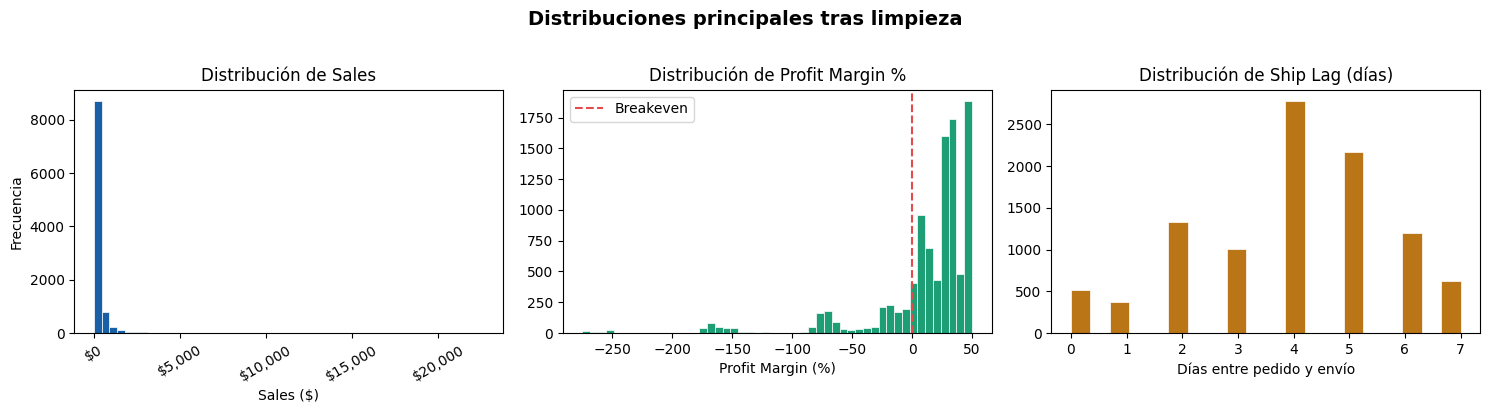

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Distribuciones principales tras limpieza", fontsize=14, fontweight="bold", y=1.02)

# Sales
axes[0].hist(df["Sales"], bins=50, color="#185FA5", edgecolor="white", linewidth=0.5)
axes[0].set_title("Distribución de Sales")
axes[0].set_xlabel("Sales ($)")
axes[0].set_ylabel("Frecuencia")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].tick_params(axis="x", rotation=30)

# Profit Margin %
axes[1].hist(df["Profit Margin %"].dropna(), bins=50, color="#1D9E75", edgecolor="white", linewidth=0.5)
axes[1].axvline(0, color="#E24B4A", linestyle="--", linewidth=1.5, label="Breakeven")
axes[1].set_title("Distribución de Profit Margin %")
axes[1].set_xlabel("Profit Margin (%)")
axes[1].legend()

# Ship Lag Days
axes[2].hist(df["Ship Lag Days"], bins=20, color="#BA7517", edgecolor="white", linewidth=0.5)
axes[2].set_title("Distribución de Ship Lag (días)")
axes[2].set_xlabel("Días entre pedido y envío")

plt.tight_layout()
#plt.savefig("images/01_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
#print("💾 Gráfico guardado en images/01_distributions.png")

## 11. Resumen del dataset limpio

In [30]:
print("=" * 55)
print("RESUMEN DEL DATASET TRAS LIMPIEZA")
print("=" * 55)
print(f"  Filas:    {len(df):,}")
print(f"  Columnas: {len(df.columns)}")
print(f"  Periodo:  {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"  Pedidos únicos:   {df['Order ID'].nunique():,}")
print(f"  Clientes únicos:  {df['Customer ID'].nunique():,}")
print(f"  Productos únicos: {df['Product ID'].nunique():,}")
print()
print("Columnas originales + columnas nuevas:")
original = 21  # columnas del raw
new_cols = len(df.columns) - original
print(f"  Originales: {original}  |  Nuevas creadas: {new_cols}")
print(f"  Total: {len(df.columns)}")
print()

# Tabla de nuevas columnas
nuevas = ["Ship Lag Days", "Year", "Month", "Month Name", "Quarter",
          "Profit Margin %", "Sales Bucket"]
print("Nuevas columnas:")
for c in nuevas:
    print(f"  + {c}")

RESUMEN DEL DATASET TRAS LIMPIEZA
  Filas:    9,994
  Columnas: 28
  Periodo:  2014-01-03 → 2017-12-30
  Pedidos únicos:   5,009
  Clientes únicos:  793
  Productos únicos: 1,862

Columnas originales + columnas nuevas:
  Originales: 21  |  Nuevas creadas: 7
  Total: 28

Nuevas columnas:
  + Ship Lag Days
  + Year
  + Month
  + Month Name
  + Quarter
  + Profit Margin %
  + Sales Bucket


## 12. Exportar dataset limpio

Guardamos el resultado en `data/superstore_clean.csv` para usarlo en los siguientes notebooks.

In [31]:
import os
os.makedirs("data", exist_ok=True)
os.makedirs("images", exist_ok=True)

df.to_csv("../data/superstore_clean.csv", index=False, encoding="utf-8")

print(" Dataset exportado correctamente.")
print(f"   Ruta:  data/superstore_clean.csv")
print(f"   Filas: {len(df):,}  |  Columnas: {len(df.columns)}")

 Dataset exportado correctamente.
   Ruta:  data/superstore_clean.csv
   Filas: 9,994  |  Columnas: 28


---

## ✅ Notebook completado

| Paso | Resultado |
|------|-----------|
| Carga del dataset | ✅ 9,994 filas · 21 columnas |
| Valores nulos | ✅ Verificados y gestionados |
| Duplicados | ✅ Eliminados si existían |
| Parsing de fechas | ✅ Order Date, Ship Date → datetime |
| Ship Lag Days | ✅ Calculado |
| Feature engineering | ✅ 7 columnas nuevas |
| Validación categórica | ✅ Sin valores inesperados |
| Export | ✅ data/superstore_clean.csv |

**Siguiente paso → `02_eda_business_insights.ipynb`**